In [1]:
# Sample dataset of reviews (expanded)
reviews = [
    "I absolutely loved this product! It exceeded all my expectations.",
    "Worst experience ever. The product broke after one use.",
    "Amazing quality and outstanding performance. Highly recommend!",
    "Terrible! Do not waste your money on this.",
    "Good value for the price. I'm satisfied.",
    "Completely disappointed. The customer service was awful.",
    "Excellent! Works perfectly and is very durable.",
    "Horrible product. It's a complete waste of money.",
    "Terrible experience with this product. It's not worth the hype.",
    "Amazing product! It has changed my life for the better.",
    "The product is not bad, but the shipping took forever.",
    "Highly recommend this! Great quality and fast delivery.",
    "I regret buying this product. It broke within a week.",
    "Best purchase ever! Exceptional quality and performance.",
    "Poor quality and terrible customer service. Avoid at all costs.",
    "Satisfied with the performance. Value for money.",
    "Awful product. The reviews were misleading."
]

# Corresponding labels
labels = [
    'Positive', 'Negative', 'Positive', 'Negative',
    'Positive', 'Negative', 'Positive', 'Negative',
    'Negative', 'Positive', 'Negative', 'Positive',
    'Negative', 'Positive', 'Negative', 'Positive',
    'Negative'
]

# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Step 1: Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(reviews, labels, test_size=0.25, random_state=42)

# Step 2: Text Preprocessing and Feature Extraction
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [13]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)  # Train the model on TF-IDF features and labels



LogisticRegression(max_iter=1000)

Accuracy: 0.40

Classification Report:
               precision    recall  f1-score   support

    Negative       0.40      1.00      0.57         2
    Positive       0.00      0.00      0.00         3

    accuracy                           0.40         5
   macro avg       0.20      0.50      0.29         5
weighted avg       0.16      0.40      0.23         5



C:\Users\rumsh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rumsh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\rumsh\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


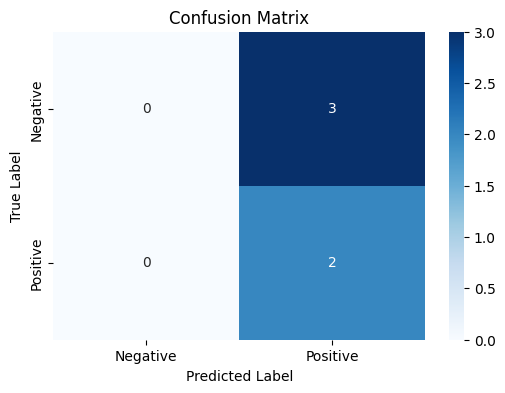

In [19]:
# Step 4: Evaluate the Model
y_pred = model.predict(X_test_tfidf)

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["Positive", "Negative"])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [21]:
# Step 5: Analyze Specific Examples
examples = [
    "The product quality is amazing. Highly recommend it!",
    "I hated the customer service. Worst experience ever!",
    "It's okay. Not great, but not bad either."
]

# Transform examples into TF-IDF features
examples_tfidf = vectorizer.transform(examples)

# Predict sentiments for the examples
predictions = model.predict(examples_tfidf)
for review, sentiment in zip(examples, predictions):
    print(f"Review: {review}\nPredicted Sentiment: {sentiment}\n")

Review: The product quality is amazing. Highly recommend it!
Predicted Sentiment: Negative

Review: I hated the customer service. Worst experience ever!
Predicted Sentiment: Negative

Review: It's okay. Not great, but not bad either.
Predicted Sentiment: Negative

